In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
# Age has missing values.
# Fill with median because age distribution contains outliers.
df["Age"] = df["Age"].fillna(df["Age"].median())
# Cabin has too many missing values.
# Drop the column because it provides insufficient usable data.
df.drop("Cabin", axis=1, inplace=True)
# Embarked has very few missing values.
# Fill with mode (most frequent value).
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

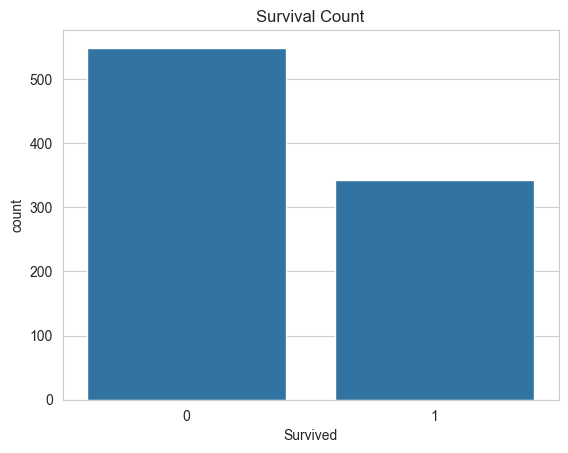

In [5]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

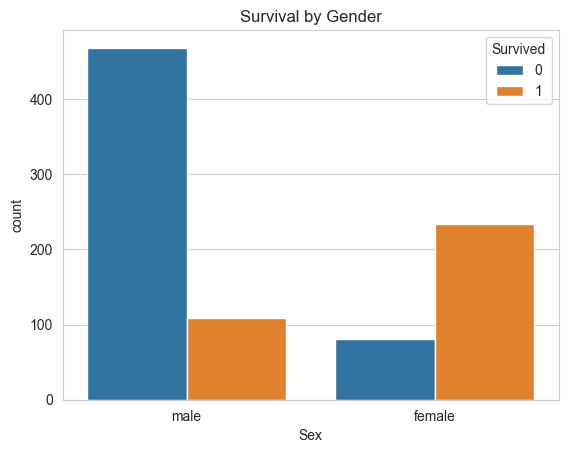

In [6]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

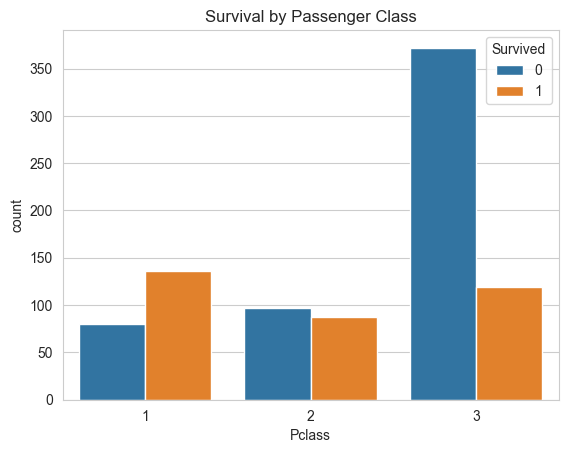

In [7]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

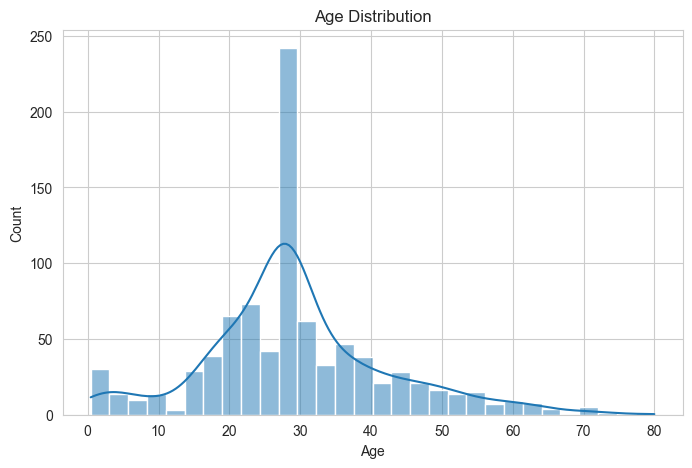

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

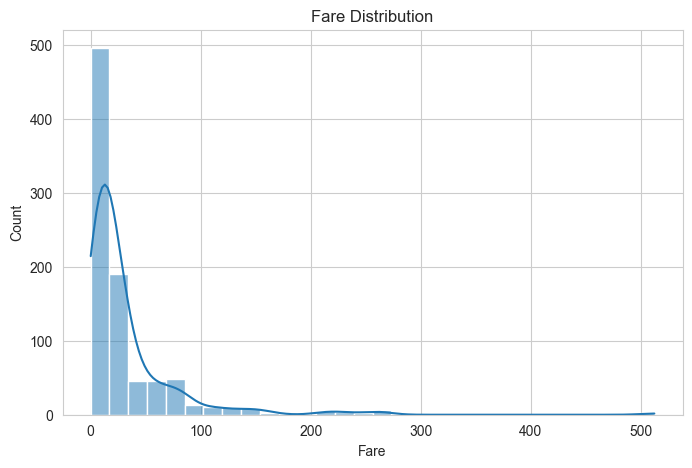

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

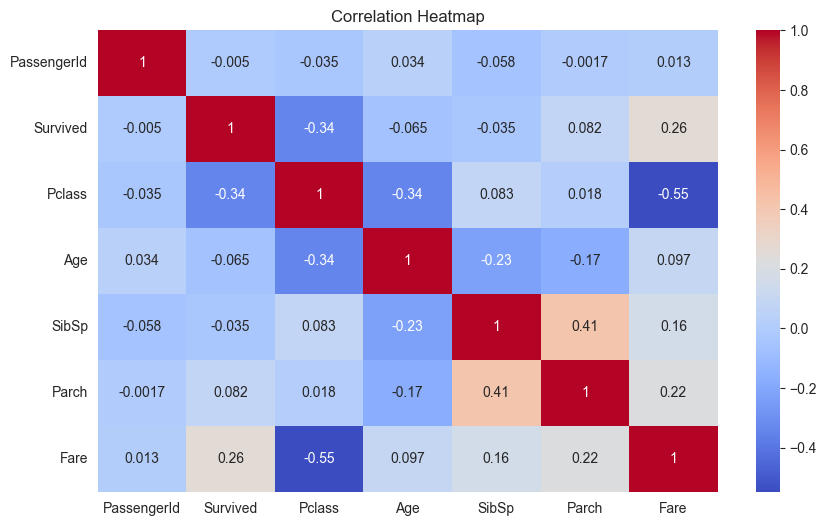

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Findings

The exploratory analysis revealed clear patterns behind passenger survival on the Titanic. Gender was the strongest factor influencing survival: women survived at much higher rates than men, supporting the historical “women and children first” evacuation policy. Passenger class also played a major role. First-class passengers had significantly better survival chances compared to third-class passengers, likely because of easier access to lifeboats and better cabin locations.

Age showed a moderate relationship with survival. Younger passengers, especially children, appeared more likely to survive than older adults. Fare distribution further supported the class-based survival trend, as passengers paying higher fares generally had better outcomes.

During data cleaning, missing Age values were replaced with the median to reduce the impact of outliers, while the Cabin column was dropped because most entries were missing. Overall, socioeconomic status and gender were the two strongest indicators of survival in the dataset.
